<a href="https://colab.research.google.com/github/bhardwajgaurav567-design/API/blob/main/Boosting_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Boosting techniques Assignment
# Question & Answers:

1. Q.  What is Boosting in Machine Learning? Explain how it improves weak
learners.

>> Boosting is an ensemble learning method in machine learning that combines multiple weak learners (models that perform slightly better than randon guessing) to create a single strong learner with significantly higher predictive accuracy.

Unlike bagging (e.g., Random Forest), where models are trained independently and in parallel, boosting trains models sequentially. Each new model focuses on correcting the mistakes (errors or misclassifications) made the previous models.

**How boosting improves weak learners:**

> It starts by training a weak learner on the original dataset(all samples have equal weight initially).

> It identifies the errors made by this model.

> The next weak learner is trained with a modified dataset that gives higher importance (higher weights) to the samples that were incorrectly predicted or had larger errors in the previous step.

> This process repeats interatively: each new weak learner specializes in the difficult/hard to predict instances that previous learners struggled with.

> Finally, all weak learner are combined (usually with weighted voting for classification or weighted averaging for regression), where better performing learners get higher influence in the final prediction.

This sequential error-correction approach reduces bias(especially) and often variance too, turning a set of simple, weak models into a powerful , accurate ensemble. Popular boosting alorithms include AdaBoost, gradient Boosting(GBM), XGBoost, LightGBM, and CatBoost.



2. Q.  What is the difference between AdaBoost and Gradient Boosting in terms
of how models are trained?


>> A. Both AdaBoost (adaptive Boosting) and Gradient Boosting are boosting algorithms that build models sequentially by focusing on previous errors, but they differ in how they identify and correct errors during training.

> **AdaBoost**.

> Primarily designed for classification (though extensions exist for regression).

> It adjusts the weights for training samples: after each weak learner (often decision stumps single level decision trees), miclassified samples get higher weights, while correctly classified ones get lower weights.

> The next weak learner is trained on this reweighted dataset, forcing it to pay more attention to difficult/hard to classify samples.

> Weak learners are combined using weighted voting, where each learner's vote is weighted by its accuracy (better models have more influence).

> It minimizes the exponential loss function implicitly through this rewighting mechanism.

> **Gradient Boosting(GBM):**

> Works for both classification and regression tasks.

> Instead of reweighting samples, it fits each new weak learner (usually decision trees) directly to the residual errors (or negative gradients of the loss function) of the current ensemble.

> The "target" for the next model is the residuals (difference between actual and predicted values) from all previous models combined.

> It uses gradient descent to minimize a differentiable loss function (e.g., mean squared error for regression, log-loss for classification) by adding small corrections (strunk by a learning rate) at each step.

> All weak learners contribute with equal weight (or scaled by learning rate), and the final predication is the additive sum of all weak learner's outputs.

**Key differences in training process:**

> AdaBoost-Focuses on reweighting misclassification/hard samples (changes the data distribution).

> Gradient Boosting-Focuses on fitting to residuals/gradients (optimizes a loss function directly via gradient descent, no explicit sample reweighting).


3. Q.  How does regularization help in XGBoost?

>> A. Regularization in XGBoost helps prevent overfitting by controlling model complexity, making the model more generalizable to unseen data. XGBoost includes built-in regularization terms in its objective function, which penalize overly complex models beyond just fitting the training data well.

Key regularization mechanisms in XGBoost:

> **L1 regularization (alpha / reg_alpha):** Adds a penalty proportional to the absoulate value of the leaf weights (L1 norm). It encourages sparsity by driving some leaf weights to exactly zero, which can lead to simplar models and implicit feature selection.

> **L2 regularization (lambda/reg_lambda):** Adds a penalty proportional to the squared value of the leaf weights (L2 norm). It shrinks leaf weights towards zero smoothly (without forcing them exactly to zero), making predictions more conservative and reducing the impact of noisy or outlier data.

> Gamma (min_split_loss): Specifies the minimum loss reduction required to make a further split on a leaf node. higher gamma values make the alorithm more conservative, resulting in fewer splits, shallower trees, and simpler models overall.

> Other related controls: Parameters like max_depth, min_child_weight, and subsample/colsample_bytree also act as regularization by limiting tree complexity and introducing.

These penalities are added directly to the loss function, so XGBoost optimizes for both accuracy (low training error) and simplicity (low compplexity). This balance reduces overfitting, expecially on noisy datasets or when there are many features, leading to better performance on validation/test data compared to unregularized gradiant boosting.



4. Q. Why is CatBoost considered efficient for handling categorical data?

>> CatBoost (categorical boosting) is specificaly designed to handle categorical feature efficiently and effectively without requiring extensive manual preprocessing (like one-hot encoding or label encoding), when often leads to high dimensionality, sparsity, or information loss.

Key reasons for its efficiency:

> **Native support for categorical features:** You simply specify which columns are categorical (using cat_features parameter); CatBoost handles them internally during training--no need for prior encoding.

> **Ordered Target Encoding (Ordered Boosting):** CatBoost uses a sophisticated form to target encoding where it calculates target statistics (e.g., mean target value per category) using only the data observed before the current example in a permuted order. This avoids target leakage (a common problem in standard target encoding that causes overfitting) and reduces prediction shift between training and testing.

> **Handling high-cardinality categories**: It efficiently manages features withmany unique values (e.g., user IDs, product codes ) without exploding dimensionality (unlike one-hot encoding, which creates thousands of columns).

> **Symmetric (oblivious ) trees: CatBoost builds symmetric decision trees where the same split is used across all nodes at the same depth. This speeds up training, reduces memory usage, and improves generalization while stil capturing interactions.

> **Reduced overfitting and better performance**: The combination of ordered boosting and efficient encoding leads to robust models with less bias from categorical preprocessing errors, often outperforming XGBoost/LightGBM on datasets with many categorical features.



5. Q. What are some real-world applications where boosting techniques are
preferred over bagging methods?

>> A. Boosting techniques (e.g., Adaboost, Gredient Boosting, XGBoost, LightGBM, CatBoost) are foten preferred over bagging methods (e.g., Random Forest) in scenarios where high predictive accuracy is critical, the data has complex patterns or noise, and sequential error correction provides better performance than variance reduction alone.

Some real-world applications where boosting is commonly preferred:

> **Financial modeling and fraud detection**: Boosting excels at handling imbalanced datasets and detecting rare events (e.g.,credit card fraud, loan default prediction) by focusing on hard to classify examples, often outperforming bagging in precision/recall.

> **Ranking systems**: (e.g., search engines, recommendation engines): XGBOost and variants are widely used in learning to rank tasks (e.g., LambdaMART) where ordered predictions matter, as boosting optimizes ranking specific losses effectively.

> Kaggle competitions and predictive analytics: Boosting models(especially XGBoost, LightGBM, CatBoost) frequently win tabular data competitions because they achieve higher accuracy by reducing bias and handling interactions/noise better than bagging.

> Medical diagnosis and healthcare prediction: Boosting is preferred for tasks like disease prediction, patient risk scoring, or survival analysis, where sequeering out every bit of accuracy from noisy/high-stakes data is essential.

> Time-series forecasting (with lagged features or when sequential patterns exist): Gradient boosting variants handle non-linear relationships and feature interactions well in demand forcasting , energy consumption prediction, or stock trend modeling.

> Customer churn prediction and marketing analytics: Boosting captures subtle patterns in customer behavior data (often categorical-heavy), leading to better identification of at risk customers compared to bagging.



6. Q.  Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy
(Include your Python code and output in the code box below.)

In [1]:
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data          # Features (30 features)
y = data.target        # Target (0 = malignant, 1 = benign)

# Print basic information about the dataset
print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target classes:", data.target_names)

# Step 2: Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y          # Ensures balanced class distribution in splits
)

print("\nTraining set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# Step 3: Create and train the AdaBoost Classifier
# Using a shallow decision tree (stump) as base estimator - common for AdaBoost
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_clf = AdaBoostClassifier(
    estimator=base_estimator,      # Weak learner (decision stump)
    n_estimators=50,               # Number of weak learners
    learning_rate=1.0,             # Default learning rate
    random_state=42
)

print("\nTraining AdaBoost Classifier...")
ada_clf.fit(X_train, y_train)

# Step 4: Make predictions on the test set
y_pred = ada_clf.predict(X_test)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("\nAdaBoost Classifier Performance:")
print(f"Accuracy on test set: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Optional: Print feature importance (from the final boosted model)
importances = ada_clf.feature_importances_
feature_names = data.feature_names

print("\nTop 5 most important features:")
indices = importances.argsort()[-5:][::-1]  # Top 5 indices
for i in indices:
    print(f"{feature_names[i]:<50} : {importances[i]:.4f}")

Dataset loaded successfully!
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

Training set size: 398
Testing set size: 171

Training AdaBoost Classifier...

AdaBoost Classifier Performance:
Accuracy on test set: 0.9591 (95.91%)

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        64
      benign       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171


Top 5 most important features:
worst concave points                               : 0.1418
worst texture                                      : 0.0993
worst radius                                       : 0.0903
mean smoothness                                    : 0.0767
worst area                                         : 0.0662


7. Q.  Write a Python program to:
● Train a Gradient Boosting Regressor on the California Housing dataset
● Evaluate performance using R-squared score
(Include your Python code and output in the code box below.)

In [2]:
# Import required libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Step 1: Load the California Housing dataset
data = fetch_california_housing()
X = data.data          # Features (8 features)
y = data.target        # Target: median house value (in $100,000s)

# Print basic information
print("California Housing Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target variable:", data.target_names[0])

# Step 2: Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining set size:", X_train.shape[0])
print("Testing set size: ", X_test.shape[0])

# Step 3: Create and train the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(
    n_estimators=100,       # Number of boosting stages
    learning_rate=0.1,      # Shrinks contribution of each tree
    max_depth=3,            # Maximum depth of individual trees
    random_state=42
)

print("\nTraining Gradient Boosting Regressor...")
gbr.fit(X_train, y_train)

# Step 4: Make predictions on the test set
y_pred = gbr.predict(X_test)

# Step 5: Evaluate performance using R-squared score
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance on Test Set:")
print(f"R-squared score: {r2:.4f} ({r2*100:.2f}%)")
print(f"Root Mean Squared Error: {rmse:.4f}")

# Optional: Show sample predictions vs actual values
print("\nSample of 5 predictions vs actual values:")
print("Actual\t\tPredicted")
for i in range(5):
    print(f"{y_test[i]:.3f}\t\t{y_pred[i]:.3f}")

California Housing Dataset loaded successfully!
Number of samples: 20640
Number of features: 8
Target variable: MedHouseVal

Training set size: 16512
Testing set size:  4128

Training Gradient Boosting Regressor...

Model Performance on Test Set:
R-squared score: 0.7756 (77.56%)
Root Mean Squared Error: 0.5422

Sample of 5 predictions vs actual values:
Actual		Predicted
0.477		0.505
0.458		1.093
5.000		4.246
2.186		2.545
2.780		2.279


8. Q.  Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy
(Include your Python code and output in the code box below.)

In [3]:
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = malignant, 1 = benign

print("Dataset loaded successfully!")
print("Samples:", X.shape[0], "| Features:", X.shape[1])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# Define XGBoost classifier
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Parameter grid - tuning only learning_rate as specified
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nPerforming Grid Search for learning rate...")
grid_search.fit(X_train, y_train)

# Best parameters and best cross-validation score
print("\n" + "="*60)
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set using the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy with best model: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

Dataset loaded successfully!
Samples: 569 | Features: 30
Train size: 426 | Test size: 143

Performing Grid Search for learning rate...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters: {'learning_rate': 0.2}
Best Cross-Validation Accuracy: 0.9671
Test Set Accuracy with best model: 0.9580 (95.80%)


9. Q. Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn
(Include your Python code and output in the code box below.)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00
Dataset loaded successfully!
Samples: 569 | Features: 30

Training CatBoost Classifier...
0:	learn: 0.5471885	total: 57.1ms	remaining: 11.4s
50:	learn: 0.0171174	total: 769ms	remaining: 2.25s
100:	learn: 0.0067174	total: 1.68s	remaining: 1.65s
150:	learn: 0.0046153	total: 2.57s	remaining: 834ms
199:	learn: 0.0037776	total: 3.44s	remaining: 0us

Test Accuracy: 0.9580 (95.80%)


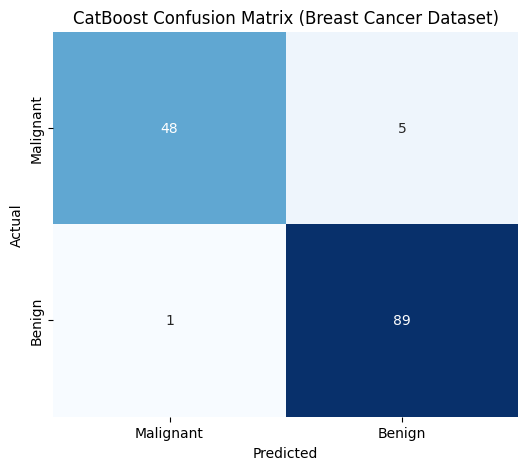

In [5]:
# Import required libraries
!pip install catboost
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset loaded successfully!")
print("Samples:", X.shape[0], "| Features:", X.shape[1])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Initialize and train CatBoost Classifier
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=50,              # Print progress every 50 iterations
    random_seed=42
)

print("\nTraining CatBoost Classifier...")
cat_model.fit(X_train, y_train)

# Predictions
y_pred = cat_model.predict(X_test)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign'],
cbar=False
)
plt.title('CatBoost Confusion Matrix (Breast Cancer Dataset)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

10. Q. You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
● Data preprocessing & handling missing/categorical values
● Choice between AdaBoost, XGBoost, or CatBoost
● Hyperparameter tuning strategy
● Evaluation metrics you'd choose and why
● How the business would benefit from your model
(Include your Python code and output in the code box below.)

>> A. Step-by-step Data science pipeline for loan default predication

1. Data Preprocessing & Handling Missing/Categorical Values

> Load & Explore Data
Check shape, data types, missing value %, vlass distribution (default rate), summary statistics , correlation heatmap, and distribution of key features.

> Handling Missing Values

- Numerical features - Median imputation (robust to outliers).

- Categorical features- Mode imputation or a new category "Missing"

- For high missing % columns (>60-70%) - consider dropping or advanced imputation (e.g., KNNImputer)

> Categorical Encoding

- Low cardinality (<10-15 unique values )- One - hot encoding.

- High cardinality (e..g, city, employer, zip code ) - Target encoding of frequency encoding
- Best choice here: CatBoost (handles categorical features natively without manual encoding).

> Feature Enginearing

- Create interaction features (e.g.m income x credit score, transaction frequency x amount)

- Time-based features (e.g, months since last default , average monthly spend).

- Binning of continuous variables (age, income, loan amount)

- Log-transform skewed features (income, transaction amounts)

In [9]:
# Required imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, fbeta_score
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')

# -------------------------------
# For demo - Create a synthetic DataFrame 'df' to simulate loan data
np.random.seed(42)
num_samples = 1000

df = pd.DataFrame({
    'age': np.random.randint(18, 70, num_samples),
    'income': np.random.normal(50000, 15000, num_samples),
    'credit_score': np.random.randint(300, 850, num_samples),
    'loan_amount': np.random.normal(10000, 5000, num_samples),
    'num_transactions': np.random.randint(5, 50, num_samples),
    'gender': np.random.choice(['Male', 'Female'], num_samples),
    'marital_status': np.random.choice(['Single', 'Married', 'Divorced'], num_samples),
    'occupation': np.random.choice(['Engineer', 'Doctor', 'Teacher', 'Artist', 'Other'], num_samples),
    'city': np.random.choice([f'City_{i}' for i in range(20)], num_samples),
    'employment_type': np.random.choice(['Salaried', 'Self-Employed', 'Unemployed'], num_samples)
})

# Simulate a target variable 'default' with imbalance (e.g., 10% default rate)
default_rate = 0.10
df['default'] = np.random.choice([0, 1], num_samples, p=[1-default_rate, default_rate])

# Introduce some missing values (e.g., 5% in income, 10% in marital_status)
for col in ['income', 'marital_status']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

print("Synthetic DataFrame created successfully with:")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]-1}")
print(f"Default rate: {df['default'].mean()*100:.2f}%")
print("Missing values summary:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Identify categorical columns (example)
cat_features = ['gender', 'marital_status', 'occupation', 'city', 'employment_type']

# Split
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle missing values in categorical features for CatBoost
# CatBoost requires NaN in categorical features to be explicitly converted to string
for col in cat_features:
    if X_train[col].isnull().any():
        X_train[col] = X_train[col].fillna('Unknown')
    if X_test[col].isnull().any():
        X_test[col] = X_test[col].fillna('Unknown')

# CatBoost Pool (handles categorical & missing natively)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test, y_test, cat_features=cat_features)

# Model with class imbalance handling
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),  # imbalance correction
    eval_metric='AUC',
    random_seed=42,
    verbose=200
)

print("\nTraining CatBoost model...")
model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=100,
    use_best_model=True
)

# Predictions & Evaluation
y_pred_proba = model.predict_proba(test_pool)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
f2 = fbeta_score(y_test, model.predict(test_pool), beta=2)

print(f"\nAUC-ROC     : {auc:.4f}")
print(f"PR-AUC      : {pr_auc:.4f}")
print(f"F2-score    : {f2:.4f}")

Synthetic DataFrame created successfully with:
Samples: 1000, Features: 10
Default rate: 9.60%
Missing values summary:
income            50
marital_status    50
dtype: int64

Training CatBoost model...
0:	test: 0.4597267	best: 0.4597267 (0)	total: 23.7ms	remaining: 35.6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.489968014
bestIteration = 60

Shrink model to first 61 iterations.

AUC-ROC     : 0.4900
PR-AUC      : 0.0978
F2-score    : 0.1562
